# Linear Regression

Project Hypotheses: 

> Students who drink alcohol more frequently during the week are associated with worse grades.

> Students who have family support at home are associated with better final grades

> Better previous grades will be associated with better final grades.

> Students who have more free time are associated with better final grades, but this will vary by sex.

> Students with larger families can be identified by their final grade in portuguese


In this section we will perform two simple linear regressions:
- One to investigate the relationship between previous grades and final grades by comparing the second grade in Portuguese (pG2) to the final grade in Portuguese (pG3).
- The second to investigate the relationship between the frequency of weekday alcohol consumption (Dalc) and the final grade in Mathematics (mG3).

We will also perform a multiple linear regression to check if the first two portuguese grades together (pG1 & pG2) are good predictors of the final grade (pG3).

Linear regressions:
1. Second portuguese vs final portuguese grade (numeric independent variable)
2. Weekday alcohol frequency vs final Mathematics grade. (categorical independent variable)

Multiple Linear regression:
- independent: First and second portuguese grades (pG1 + pG2)
- dependent: final portuguese grade (pG3)


In [203]:
# import relevant packages
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import math
from IPython.display import Markdown as md

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.nonparametric.smoothers_lowess as sml
import statsmodels.stats.outliers_influence as smi
import statsmodels.stats.api as sms
import patsy.contrasts as contr

%run utils.py

In [204]:
full_df = pd.read_csv("prepared_dataset.csv")
full_df.head()

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
0,0,GP,F,15,R,GT3,T,1,1,at_home,...,3,1,2,1,1,1,4,13,13,13
1,1,GP,F,15,R,GT3,T,1,1,other,...,3,3,4,2,4,5,2,13,11,11
2,2,GP,F,15,R,GT3,T,2,2,at_home,...,4,3,1,1,1,2,8,14,13,12
3,3,GP,F,15,R,GT3,T,2,4,services,...,4,3,2,1,1,5,2,10,11,10
4,4,GP,F,15,R,GT3,T,3,3,services,...,4,2,1,2,3,3,2,13,13,13


# Linear Regression

Linear regressions are used to gain information about relationships between the independent and dependent variables.

The dependent variables in this project are the final grades in Maths (mG3) and Portuguese (pG3).

### Regression 1: 

Comparing the second Portuguese Grade with the Final Portuguese grade.

Numeric independent variable: Second portuguese grade pG2

Numeric dependent variable: Final portuguese grade pG3

In [205]:
# prepare the dataset
df1 = full_df[['pG2', 'pG3']]
df1.head()

,pG2,pG3
0,13,13
1,11,11
2,13,12
3,11,10
4,13,13


In [206]:
# add constant and fit model using OLS
df1 = sm.add_constant(df1)
model1 = sm.OLS(df1['pG3'], df1.iloc[:,:-1]).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    pG3   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     1397.
Date:                Fri, 22 Dec 2023   Prob (F-statistic):          2.33e-127
Time:                        05:39:31   Log-Likelihood:                -633.89
No. Observations:                 370   AIC:                             1272.
Df Residuals:                     368   BIC:                             1280.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4800      0.356     -1.350      0.1

The *$R^2$* value (*$R^2$* = .792) of the linear regression comparing pG2 and pG3 shows that 78% of the variation in the final Portuguese grade can be explained by pG2, the second Portuguese grade. 

The effect size found by looking at the *$R^2$* value indicates a large effect, meaning that pG2 is a good predictor for pG3.

The F-statistic (*F* = 1397, *p* < 0.001) and low *p*-value, shows that the results are highly significant at a 95% level of confidence.


Overall, the model shows a strong positive relationship between the second portuguese grade (pG2) and the final grade in Portuguese (pG3), suggesting that the previous grade is a significant predictor of the final grade.

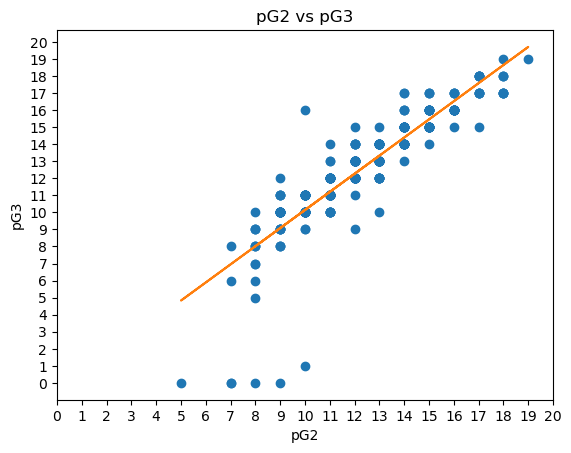

In [207]:
func = np.poly1d(list(reversed(model1.params))) 
plt.plot(df1['pG2'], df1['pG3'], 'o', df1['pG2'], func(df1['pG2']), '-') 

plt.xticks(ticks=range(0,21), labels=range(0,21))
plt.yticks(ticks=range(0,21), labels=range(0,21))
plt.title('pG2 vs pG3')
plt.xlabel('pG2')
plt.ylabel('pG3')

plt.show()

Looking at the plot we can see that the regression line found by the model matches well with the shape of pG2 and pG3.

### Checking the assumptions for the linear regression comparing pG2 to pG3

These are important to understand the model, prevent over or underfitting the model.

If the relationship between the variables is not linear, the model will be underfitted. If there are too many independent variables compared to the number of instances, the model will be overfitted.

### Normality tests of residuals

#### Normal distribution of residuals
##### Visual inspection - Histogram + Q-Q Plot

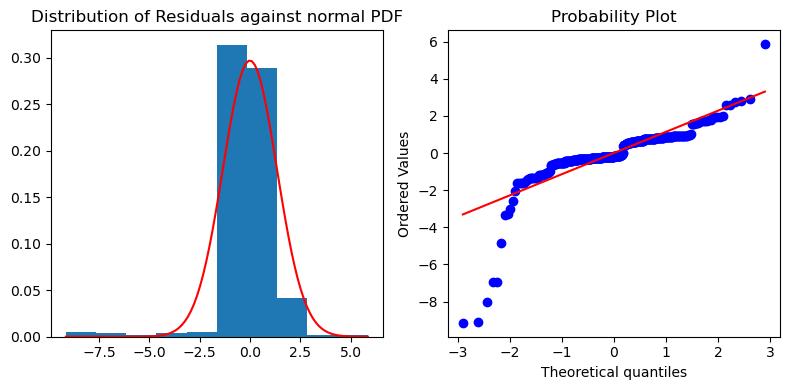

In [208]:
plt.figure(figsize=(8, 4), tight_layout = True)

plt.subplot(121)
plot_hist_and_norm_pdf(model1.resid, standardize=False, bins=10)
plt.title("Distribution of Residuals against normal PDF")

plt.subplot(122)
ss.probplot(model1.resid, plot=plt)

plt.show()

#### Percentage of values over 2 standard deviations from mean

In [209]:
# percentage of values over 2 standard deviations
print(pc_over_2sd(model1.resid))
#print((model1.resid).mean)

#mean of model1.resid
print(model1.resid.mean())

3.5135135135135136
6.625330914519853e-16


#### Goodness of fit test

In [210]:
ss.shapiro(model1.resid)

ShapiroResult(statistic=0.7212115526199341, pvalue=2.130734604246394e-24)

Normality tests results:

The plot of the distribution of residuals against a normal PDF curve, and the q-q plot of the residuals suggests that the distribution is not likely to be normal.

The mean of the residuals was close to zero (*M* = 6.625e-16).
However, over 58% of values lie over 2 standard deviations from the mean. Again, this suggests non-normality.

The goodness of fit Shapiro-Wilk's test (*W* = 0.72, *p* = <0.001) indicates that the data is significantly non-normally distributed at a 95% confidence level. 
 
In conclusion, the distribution of residuals can not be considered normal.



#### Variance of predictors


In [211]:
df1['pG3'].var()

8.665091921189484

The variance of pG3, the dependent variable (*Var* = 8.67) is non-zero

#### Linearity of the dependency


##### Visual Inspection - Residual Plot

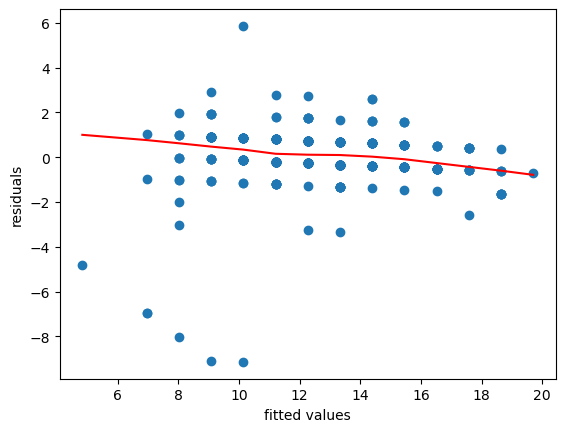

In [212]:
plt.scatter(model1.fittedvalues, model1.resid)
smth_curve = sml.lowess(model1.resid, model1.fittedvalues).T
plt.plot(smth_curve[0], smth_curve[1], color='red')
plt.xlabel('fitted values')
plt.ylabel('residuals')

plt.show()

Since the line on the residual plot is straight, the dependency can be considered linear.

#### Homoskedasticity

##### Visual inspection - Scale-location plot

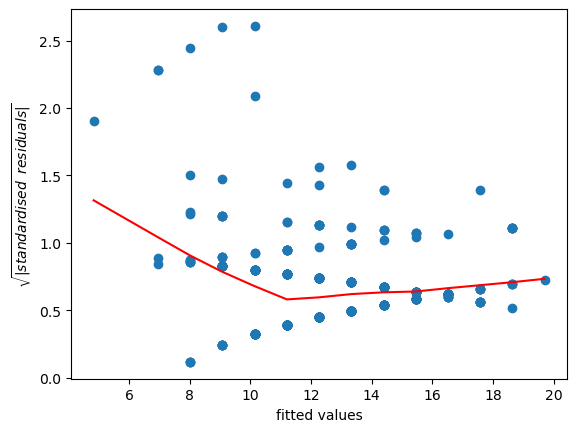

In [213]:
sqrt_vf = np.vectorize(lambda x: math.sqrt(abs(x)))
influence = smi.OLSInfluence(model1)
sqrt_abs_stud_resid = sqrt_vf(influence.resid_studentized_internal)
plt.scatter(model1.fittedvalues, sqrt_abs_stud_resid)
plt.xlabel('fitted values')
plt.ylabel('$\sqrt{|standardised\;\;residuals|}$')

smth_curve = sml.lowess(sqrt_abs_stud_resid, model1.fittedvalues).T
plt.plot(smth_curve[0], smth_curve[1], color='red')

plt.show()

In [214]:
l, lp, f, fp = sm.stats.het_breuschpagan(model1.resid, model1.model.exog, robust=False)
md(f'Lagrange multiplier statistic: {1:.2f}, p-value: {lp:.3f}\n\nF: {f:.2f}, p-value {fp:.3f}')

Lagrange multiplier statistic: 1.00, p-value: 0.000

F: 16.99, p-value 0.000

The line is not very straight, meaning that the distribution is not considered homoskedastic.
This is confirmed by the Lagrange multiplier statistic (stat = 1, *p* = .0), and the F statistic (*F* = 16.99, *p* = .0), both of which are significant at 95% confidence. 

This does not meet the assumption of homoskedasticity.

#### No perfect Multicollinearity
Values of the Variance Inflation Factor (VIF) between 5 and 10 are moderate and over 10 not acceptable.

In [215]:
smi.variance_inflation_factor(model1.model.exog, 1)

0.9999999999999998

The model shows low multicollinearity (*VIF* = 1), matching the assumptions.

#### Independent Errors

The Durbin-Watson test statistic (*DW* = 1.893) shows that there is very little autocorrelation.

*DW* values lie between 0 and 4, and a *DW* value of 2 indicates no autocorrelation. [\[1\]](https://www.investopedia.com/terms/d/durbin-watson-statistic.asp)

This meets the assumption of independent errors.

#### Summary of assumption tests for LR pG2 vs pG3:
|Assumption| met/unmet|
|--|--|
|Non-zero variance in predictor variables| met |
|No perfect multicollinearity| met |
|Homoskedasticity| unmet | 
|Independent errors| met |
|Normally distributed errors| unmet |
|Linearity| met |


## Diagnostics

Checking for values that stand out from the rest or that have a disproportionate effect on the model.

In this case we are looking for students whose second portuguese grade and final portuguese grade had a large effect on the model. This will show us if there are students who are overly contributing or skewing the model.

#### Cook's Distance

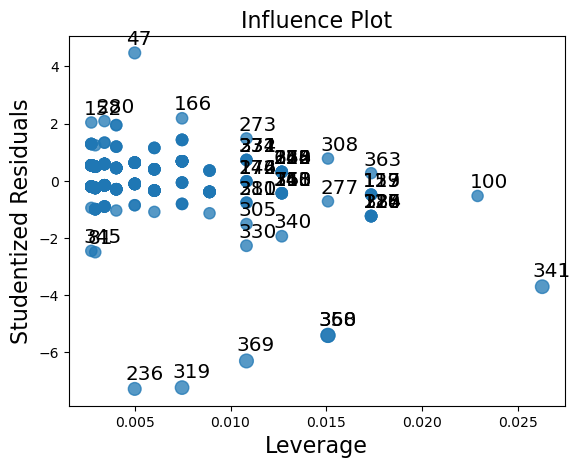

In [216]:
figure = sm.graphics.influence_plot(model1, criterion="cooks", size=10)

In [217]:
cooks_d_list = model1.get_influence().cooks_distance[0]

print("Min:", cooks_d_list.min())
print("Max:", cooks_d_list.max())
print("Mean:", cooks_d_list.mean())
print()

Min: 9.86525502139462e-07
Max: 0.2077189657446722
Mean: 0.004332769548608312



The low mean cook's distance suggests that although there are outliers, their influence is low.

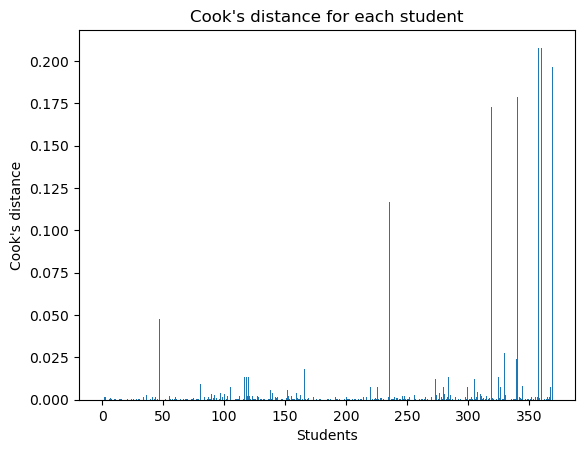

In [218]:
plt.bar(range(0, len(cooks_d_list)), cooks_d_list)
plt.title('Cook\'s distance for each student')
plt.xlabel('Students')
plt.ylabel('Cook\'s distance')

plt.show()

There are a number of students whose data stands out as an outlier, as evident on the bar plot.

In [219]:
# get outliers above a threshold of 0.02
high_cooks_distance_students = {i: dist for i, dist in enumerate(cooks_d_list) if dist > 0.02}
high_cooks_distance_students

{47: 0.0478428431057933,
 236: 0.11655027671680729,
 319: 0.17261627121747397,
 330: 0.02783769357452936,
 340: 0.02386244429620508,
 341: 0.1785155208097049,
 358: 0.2077189657446722,
 360: 0.2077189657446722,
 369: 0.19648661981449217}

Text(0, 0.5, 'pG3')

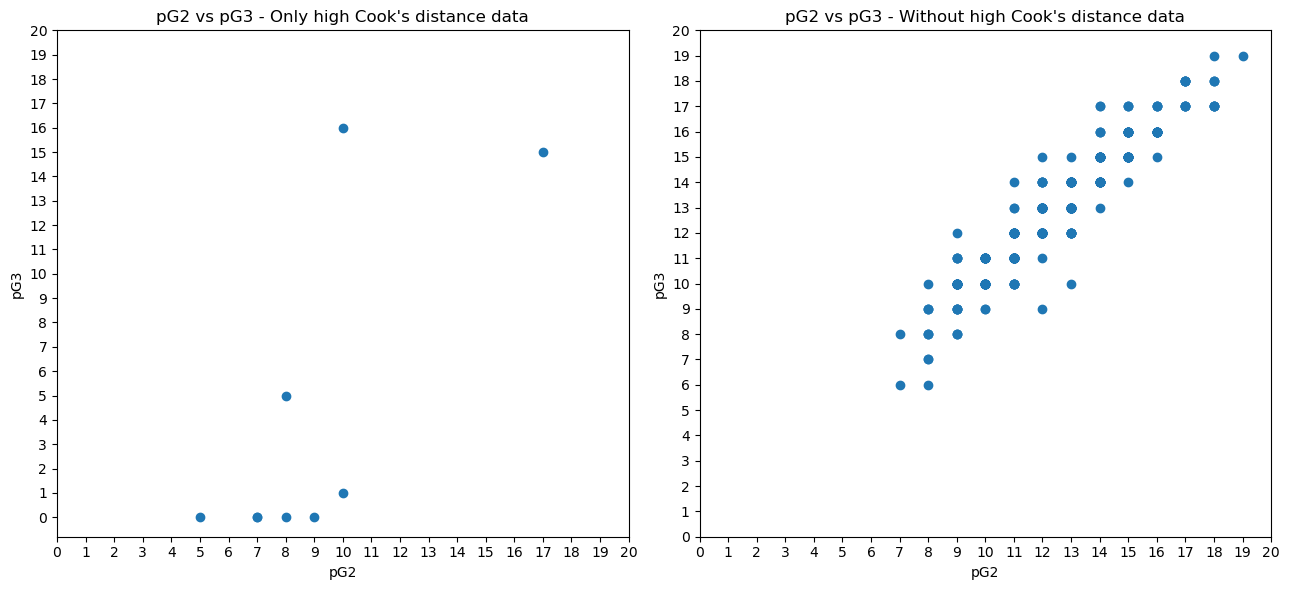

In [220]:
# show the full_df dataframe where the index is in the dict of high_cooks_distance 

top_cooks_df = full_df.loc[high_cooks_distance_students.keys()][["pG2", "pG3"]]

plt.figure(figsize=(13,6), tight_layout=True)
plt.subplot(121)
plt.scatter(top_cooks_df["pG2"], top_cooks_df["pG3"])
plt.xlim(0,6)
plt.xticks(range(0,21))
plt.yticks(range(0,21))
plt.xlabel("pG2")
plt.ylabel("pG3")
plt.title("pG2 vs pG3 - Only high Cook's distance data")

plt.subplot(122)
not_top_cooks_df = full_df.drop(high_cooks_distance_students.keys())[["pG2", "pG3"]]

plt.scatter(not_top_cooks_df["pG2"], not_top_cooks_df["pG3"])
plt.xlim(0,6)
plt.xticks(range(0,21))
plt.yticks(range(0,21))
plt.title("pG2 vs pG3 - Without high Cook's distance data")
plt.xlabel("pG2")
plt.ylabel("pG3")

The students who are influencing the model the most appear mainly to be students who have likely failed the final grading in portuguese, but who did satisfactorily in the second grading. The mean cook's distance is low (M = 0.004) suggesting that removing the outliers is unlikely to have much of an effect on the linear regression.

#### Summary of findings

The linear regression results indicate a strong positive relationship between second  Portuguese grades (pG2) and final Portuguese grades (pG3), with pG2 accounting for 79.2% of the variance in pG3 ($R^2 = 0.792$, $F(1, 368) = 1397$, $p < .001$), though the model's assumptions of homoskedasticity and normally distributed errors were not met.

There were some outliers indicated by the Cook's distance analysis. These were students who received a 0 grade for some reason. It is possible that they did not attend the final grading, however it seems unusual that they would have completed the second grading without issues.

# Regression 2:
Categorical independent variable

Comparing the relationship between Dalc and pG3.

Dalc is a categorical ordinal variable. Categories are represented by integers 1 - 5 for the frequency of alcohol consumption during the week. pG3 is a numeric variable.



In [221]:
df2 = full_df[["pG3","Dalc"]]
df2["Dalc"].value_counts()

1    258
2     71
3     24
5      9
4      8
Name: Dalc, dtype: int64

In [222]:
model2 = smf.ols("pG3 ~ Dalc", data=df2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    pG3   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     30.96
Date:                Fri, 22 Dec 2023   Prob (F-statistic):           5.09e-08
Time:                        05:39:34   Log-Likelihood:                -909.04
No. Observations:                 370   AIC:                             1822.
Df Residuals:                     368   BIC:                             1830.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.9116      0.285     48.823      0.0

The *$R^2$* value (*$R^2$* = .078) of the linear regression comparing pG2 and pG3 shows that 7.8% of the variation in the final Portuguese grade can be explained by the frequency of alcohol consumption. 

The effect size found by looking at the *$R^2$* value indicates a small effect, meaning that Dalc is not a good predictor for pG3.

The F-statistic (*F* = 30.96, *p* < 0.001) and low *p*-value, shows that the results are highly significant at a 95% level of confidence.



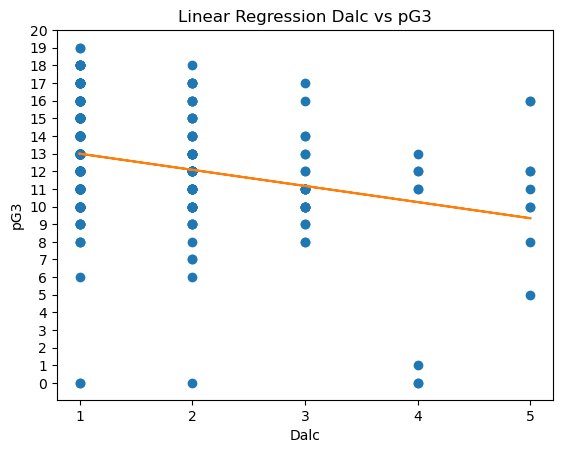

In [223]:
func = np.poly1d(list(reversed(model2.params))) 
plt.plot(df2['Dalc'], df2['pG3'], 'o', df2['Dalc'], func(df2['Dalc']), '-') 

plt.xticks(ticks=range(1,6), labels=range(1,6))
plt.yticks(ticks=range(0,21), labels=range(0,21))
plt.title('Linear Regression Dalc vs pG3')
plt.xlabel('Dalc')
plt.ylabel('pG3')

plt.show()

From the plot of Dalc vs pG3 we can see that the line does not fit the shape of the data particularly well. 

0 13.023255813953488
1 12.028169014084508
2 11.291666666666666
3 7.5
4 11.11111111111111


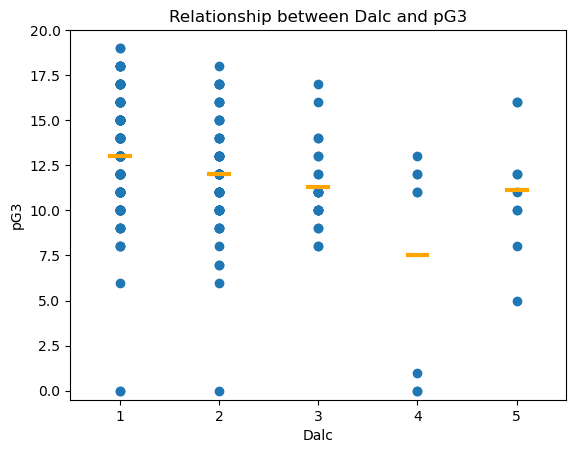

In [224]:
# prepare data 
#----------------
# arrange the values of Dalc into the order in which they appear in the model
dalc_unique_arranged =  sorted(list( df2['Dalc'].unique()))

# plot
#--------------
# plot the values
plt.plot(df2['Dalc'], df2['pG3'], 'o')
# plot the means
means = df2.groupby(df2["Dalc"])['pG3'].mean()[dalc_unique_arranged]
for i, m in enumerate(means):
    print(i,m)
    plt.plot([i+1-0.1, i+1+0.1], [m, m], color='orange', linewidth=3)
# ticks and limits
plt.xlim([0.5, 5.5])
plt.ylim([-0.5, 20])
plt.xticks(ticks=range(1,len(dalc_unique_arranged)+1), labels=dalc_unique_arranged)
plt.title('Relationship between Dalc and pG3')
plt.xlabel('Dalc')
plt.ylabel('pG3')
plt.show()

### Assumption checks


#### Normality of residuals

##### Visual inspection - Histogram + Q-Q Plot

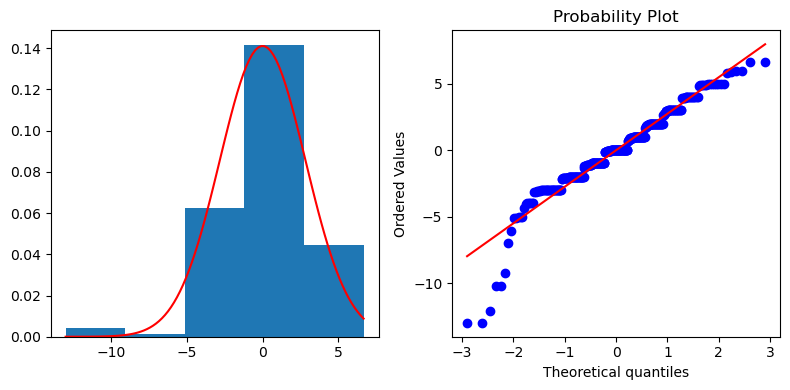

In [225]:
plt.figure(figsize=(8, 4), tight_layout = True)

plt.subplot(121)
plot_hist_and_norm_pdf(model2.resid, standardize=False, bins=5)

plt.subplot(122)
ss.probplot(model2.resid, plot=plt)

plt.show()

#### Percentage of values over 2 standard deviations from mean

In [226]:
# percentage of values over 2 standard deviations
print("% > 2 SD:", pc_over_2sd(model2.resid))
#print((model1.resid).mean)

#mean of model2.resid
print("Mean of residuals: ", model2.resid.mean())

% > 2 SD: 3.783783783783784
Mean of residuals:  -3.0726172357193523e-15


#### Goodness of fit test

In [227]:
ss.shapiro(model2.resid)

ShapiroResult(statistic=0.9405323266983032, pvalue=5.1514809779051873e-11)

Normality tests results:

The plot of the distribution of residuals against a normal PDF curve, and the q-q plot of the residuals suggests that the distribution is not likely to be normal.

The mean of the residuals was close to zero (*M* = -3.0726172357193523e-15).
However, over 47% of values lie over 2 standard deviations from the mean. Again, this suggests non-normality.

The goodness of fit Shapiro-Wilk's test (*W* = 0.94, *p* = <0.001) indicates that the data is significantly non-normally distributed at a 95% confidence level. 
 
In conclusion, the distribution of residuals can not be considered normal.

#### Variance of predictors


In [228]:
df1['pG3'].var()

8.665091921189484

The variance of pG3, the dependent variable (*Var* = 8.67) is non-zero. This meets the assumption of non-zero variance of predictors.

#### Checking the Linearity of the dependency

c:\Users\garve\anaconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


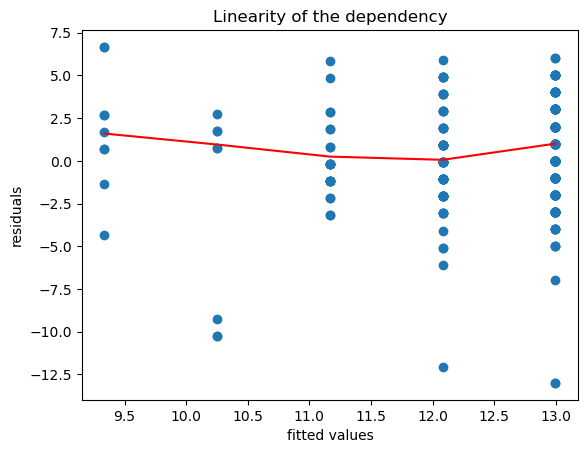

In [229]:
# Linearity of the dependency

plt.scatter(model2.fittedvalues, model2.resid)
smth_curve = sml.lowess(model2.resid, model2.fittedvalues).T
plt.plot(smth_curve[0], smth_curve[1], color='red')
plt.xlabel('fitted values')
plt.ylabel('residuals')

plt.title('Linearity of the dependency')

plt.show()

The line is reasonably straight, therefore the dependency can be considered to be linear.

The assumption of linearity of the dependency is met.

#### Test for Homoskedasticity
Homoskedasticity is the 
Homoskedasticity can be tested with a scale-location plot and with a hypothesis test. 

##### Scale-location plot

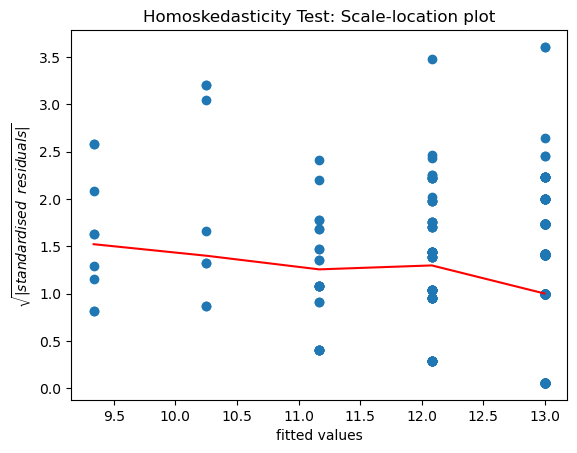

In [230]:
sqrt_vf = np.vectorize(lambda x: math.sqrt(abs(x)))
influence = smi.OLSInfluence(model2)
sqrt_abs_resid = sqrt_vf(model2.resid)
plt.scatter(model2.fittedvalues, sqrt_abs_resid)
plt.xlabel('fitted values')
plt.ylabel('$\sqrt{|standardised\;\;residuals|}$')
plt.title("Homoskedasticity Test: Scale-location plot")
smth_curve = sml.lowess(sqrt_abs_resid, model2.fittedvalues).T
plt.plot(smth_curve[0], smth_curve[1], color='red')

plt.show()

In [231]:
l, lp, f, fp = sm.stats.het_breuschpagan(model2.resid, model2.model.exog, robust=False)
md(f'Lagrange multiplier statistic: {1:.2f}, p-value: {lp:.3f}\n\nF: {f:.2f}, p-value {fp:.3f}')

Lagrange multiplier statistic: 1.00, p-value: 0.000

F: 8.04, p-value 0.005

The non-straight line indicates that the residuals are not homoskedastic. This is confirmed by the Lagrange multiplier statistic (stat = 1, *p* = .0), and the F statistic (*F* = 8.04, *p* = 0.005), both of which are significant at 95% confidence. 

This does not meet the assumption of homoskedasticity.

##### Testing for Multicollinearity

In [232]:
smi.variance_inflation_factor(model2.model.exog, 1)

1.0000000000000002

The Variance Inflation Factor (*VIF* = 1) shows a low level of multicollinearity.

This meets the assumptions of no perfect multicollinearity.

#### Independent Errors

The Durbin-Watson test statistic (*DW* =  1.936) shows that there is very little autocorrelation.

*DW* values lie between 0 and 4, and a *DW* value of 2 indicates no autocorrelation. [\[1\]](https://www.investopedia.com/terms/d/durbin-watson-statistic.asp)

This meets the assumption of independent errors.

#### Summary of assumption tests:
|Assumption| met/unmet|
|--|--|
|Non-zero variance in predictor variables| met |
|No perfect multicollinearity| met |
|Homoskedasticity|unmet|
|Independent errors|met|
|Normally distributed errors|unmet|
|Linearity|met |




### Diagnostics

Checking for extreme cases:
- outliers
- leverage
- influential cases

#### Cook's distance

Identifying data points that are influential on the model. In this case we are looking for students whose alcohol consumption and final grades had a large effect on the model. This will show us if there are students who are overly contributing or skewing the model.

Find values that stand out, or that are at least 0.5 or 1.

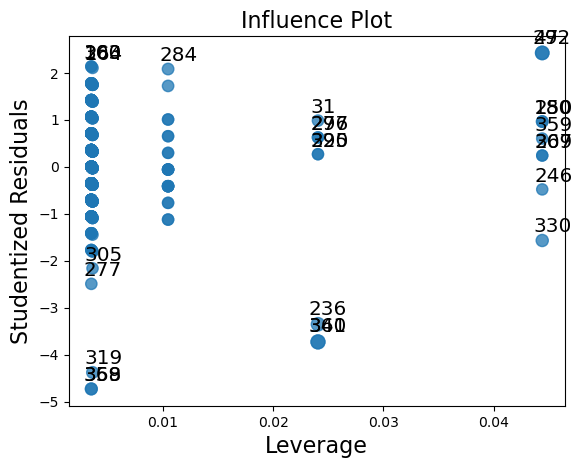

In [233]:
figure = sm.graphics.influence_plot(model2, criterion="cooks", size=10)

In [234]:
cooks_d_list = model2.get_influence().cooks_distance[0]

print("Min:", cooks_d_list.min())
print("Max:", cooks_d_list.max())
print("Mean:", cooks_d_list.mean())
print()
#print("Top 30 Cook's Distance values: ")
#sorted(cooks_d_list)[::-1][:10]


Min: 2.443675073434543e-09
Max: 0.16566258057623934
Mean: 0.004011557831428232



The low mean value of the Cook's distance (M = 0.004) suggests that the outliers are not particularly influential.

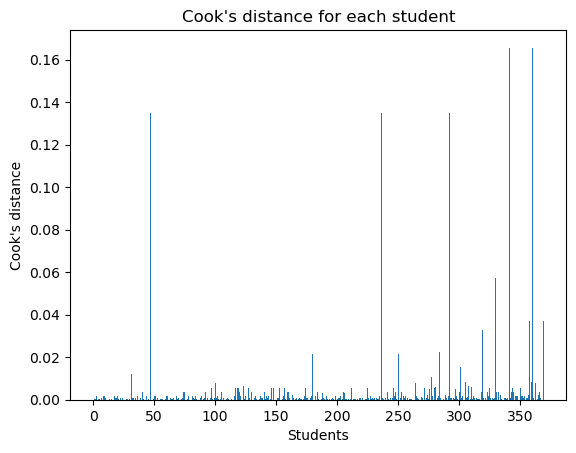

In [235]:
plt.bar(range(0, len(cooks_d_list)), cooks_d_list)
plt.title('Cook\'s distance for each student')
plt.xlabel('Students')
plt.ylabel('Cook\'s distance')

plt.show()

There are a number of student's whose data stands out from the rest of the data. These are disproportionately influential on the model.

In [236]:
# get outliers above a threshold of 0.02
high_cooks_distance_students = {i: dist for i, dist in enumerate(cooks_d_list) if dist > 0.01}
high_cooks_distance_students

{31: 0.011902627242633228,
 47: 0.13471544297698929,
 180: 0.02151787957291527,
 236: 0.1349206504621639,
 250: 0.02151787957291527,
 277: 0.010740658994507005,
 284: 0.02267296982976722,
 292: 0.13471544297698929,
 301: 0.015565447892381127,
 319: 0.033037267787031505,
 330: 0.05708097904331638,
 341: 0.16566258057623934,
 358: 0.03706062591159839,
 360: 0.16566258057623934,
 369: 0.03706062591159839}

Text(0.5, 1.0, "Dalc vs pG3 - Without high Cook's distance data")

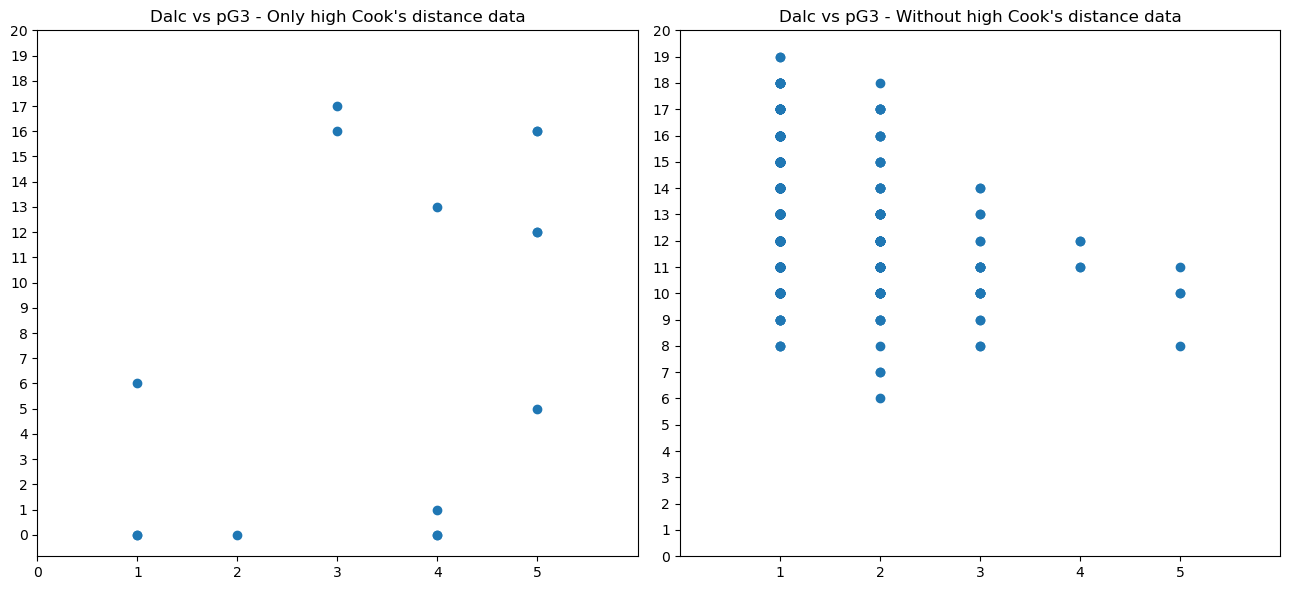

In [237]:
# show the full_df dataframe where the index is in the dict of high_cooks_distance 

top_cooks_df = full_df.loc[high_cooks_distance_students.keys()][["Dalc", "pG3"]]

plt.figure(figsize=(13,6), tight_layout=True)
plt.subplot(121)
plt.scatter(top_cooks_df["Dalc"], top_cooks_df["pG3"])
plt.xlim(0,6)
plt.xticks(range(0,6))
plt.yticks(range(0,21))
plt.title("Dalc vs pG3 - Only high Cook's distance data")
plt.subplot(122)
not_top_cooks_df = full_df.drop(high_cooks_distance_students.keys())[["Dalc", "pG3"]]

plt.scatter(not_top_cooks_df["Dalc"], not_top_cooks_df["pG3"])
plt.xlim(0,6)
plt.xticks(range(1,6))
plt.yticks(range(0,21))
plt.title("Dalc vs pG3 - Without high Cook's distance data")

The students who are influencing the model the most appear to be students who drink who fall on the extremes of alcohol consumption and final grades.

Without the high cook's distance data points, there are no students who drink frequently (at 4 or 5), who also received a very high final grade in Portuguese.


### Linear regression 2 Summary: 

The model indicates a negative relationship between weekday alcohol consumption (Dalc) and final grades in Portuguese. As the frequency of weekday alcohol  increases, the final grade tends to decrease.

The linear regression shows that weekday alcohol consumption (Dalc) negatively correlates with final Portuguese grades (pG3), accounting for approximately 7.8% of the variance in grades ($R^2 = 0.078$, $F(1, 368) = 30.96$, $p < .001$), however the assumptions of homoskedasticity and normally distributed errors were not met.


# Multiple Linear regression

Comparing the first (pG1) and second (pG2) Portuguese grades with the final grade (pG3).

In [238]:
df3 = full_df[["pG1", "pG2", "pG3"]]
df3.shape

(370, 3)

In [239]:
model3 = smf.ols("pG3 ~ pG1 + pG2", data=df3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    pG3   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     713.1
Date:                Fri, 22 Dec 2023   Prob (F-statistic):          3.80e-127
Time:                        05:39:37   Log-Likelihood:                -630.50
No. Observations:                 370   AIC:                             1267.
Df Residuals:                     367   BIC:                             1279.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6129      0.357     -1.719      0.0



*$R^2$* = .795 

F-statistic, (*F* = 713.1, *p* < 0.001)


The *$R^2$* value (*$R^2$* = .795) of the linear regression comparing pG1 and pG2 to pG3 shows that 78% of the variation in the final Portuguese grade can be explained by pG1 and pG2. 

The effect size found by looking at the *$R^2$* value indicates a large effect, meaning that pG1 and pG2 are good predictors of pG3.

The F-statistic (*F* = 713.1, *p* < 0.001) and low *p*-value, shows that the results are highly significant at a 95% level of confidence.




## Assumption checking:


### Normality of residuals

#### Visual inspection - Histogram and Q-Q Plot

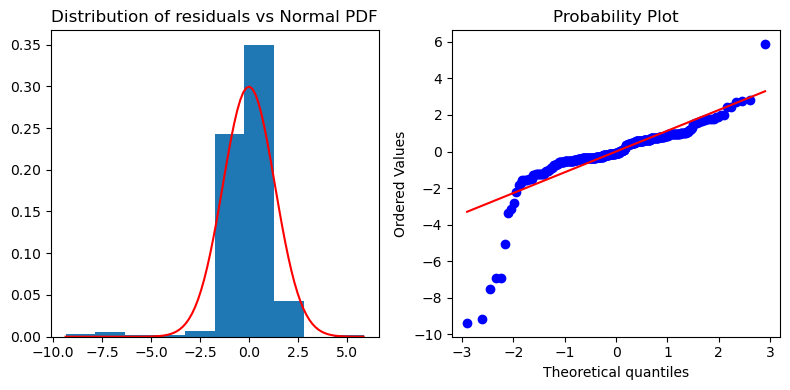

In [240]:
plt.figure(figsize=(8, 4), tight_layout = True)

plt.subplot(121)
plot_hist_and_norm_pdf(model3.resid, standardize=False, bins=10)

plt.title("Distribution of residuals vs Normal PDF")

plt.subplot(122)
ss.probplot(model3.resid, plot=plt)

plt.show()

#### Skewness and Kurtosis of residuals

In [241]:
print("Skewness:", round(ss.skew(model3.resid)/se_skew(len(model3.resid)), 3))
print("Kurtosis:", round(ss.kurtosis(model3.resid, fisher=True)/se_kurt(len(model3.resid)), 3))

Skewness: -22.891
Kurtosis: 74.06


##### Percentage of values outside of 2 standard deviations

In [242]:
pc_over_2sd(model3.resid)

3.5135135135135136

Goodness of fit test

In [243]:
W = ss.shapiro(model3.resid)
print(W)

ShapiroResult(statistic=0.7294750809669495, pvalue=4.406913071310196e-24)


#### Summary of normality tests 

The skewness and kurtosis scores (*Skew* = -22.891, *Kurtosis* = 74.06) suggest that the distribution is skewed to the left and the tails contain many outliers.

Over 53% of residual values lie over 2 standard deviations from the mean, suggesting non-normality of the distribution of residuals.

The Shapiro-Wilks goodness of fit test (*W* = 0.73, *p* < 0.001) indicates that the residuals are not normally distributed.

In conclusion, the distribution of residuals can not be considered normal.


### Variance of predictors

In [244]:
df3['pG3'].var()

8.665091921189484

The variance of the predictor (*Var* = 8.66) is not zero, therefore meeting the assumption of non-zero variance of predictors.


### Linearity of the dependency

##### Visual inspection - Residual plot

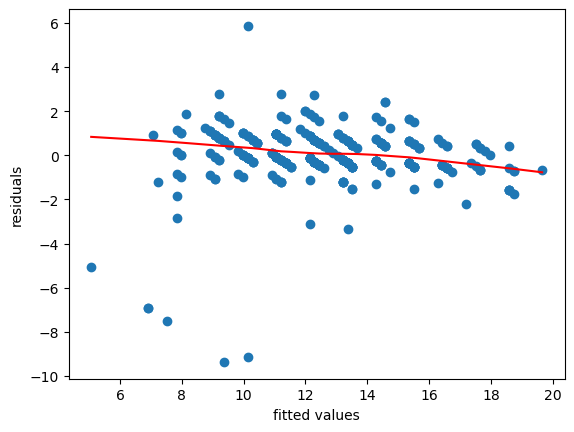

In [245]:
plt.scatter(model3.fittedvalues, model3.resid)
smth_curve = sml.lowess(model3.resid, model3.fittedvalues).T
plt.plot(smth_curve[0], smth_curve[1], color='red')
plt.xlabel('fitted values')
plt.ylabel('residuals')

plt.show()


Since the line on the residual plot is straight, the dependency can be considered linear.


### Homoskedasticity

#### Visual inspection of scale-location plot

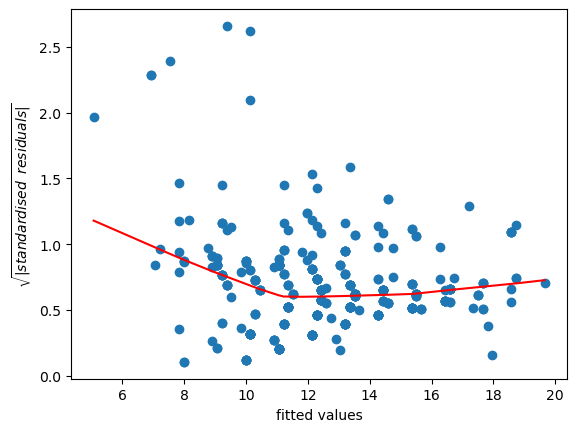

In [246]:
sqrt_vf = np.vectorize(lambda x: math.sqrt(abs(x)))
influence = smi.OLSInfluence(model3)
sqrt_abs_stud_resid = sqrt_vf(influence.resid_studentized_internal)
plt.scatter(model3.fittedvalues, sqrt_abs_stud_resid)
plt.xlabel('fitted values')
plt.ylabel('$\sqrt{|standardised\;\;residuals|}$')

smth_curve = sml.lowess(sqrt_abs_stud_resid, model3.fittedvalues).T
plt.plot(smth_curve[0], smth_curve[1], color='red')

plt.show()

In [247]:
l, lp, f, fp = sm.stats.het_breuschpagan(model3.resid, model3.model.exog, robust=False)
md(f'Lagrange multiplier statistic: {1:.2f}, p-value: {lp:.3f}\n\nF: {f:.2f}, p-value {fp:.3f}')

Lagrange multiplier statistic: 1.00, p-value: 0.000

F: 8.45, p-value 0.000

The line is not very straight, meaning that the distribution is not considered homoskedastic.
This is confirmed by the Lagrange multiplier statistic (stat = 1, *p* = .0), and the F statistic (*F* = 8.45, *p* = .0), both of which are significant at 95% confidence. 

This does not meet the assumption of homoskedasticity.

### No perfect multicollinearity

VIF between 5 and 10 are moderate. Over 10 is not acceptable

In [248]:
smi.variance_inflation_factor(model3.model.exog, 2)

4.708582911760093

The model shows moderate multicollinearity (*VIF* = 4.7), matching the assumptions.

#### Independent Errors

The Durbin-Watson test statistic (*DW* = 1.928) shows that there is very little autocorrelation.

*DW* values lie between 0 and 4, and a *DW* value of 2 indicates no autocorrelation. [\[1\]](https://www.investopedia.com/terms/d/durbin-watson-statistic.asp)

This meets the assumption of independent errors.

#### Summary of assumption tests for LR pG1 + pG2 vs pG3:
|Assumption| met/unmet|
|--|--|
|Non-zero variance in predictor variables| met |
|No perfect multicollinearity| met |
|Homoskedasticity| unmet | 
|Independent errors| met |
|Normally distributed errors| unmet |
|Linearity| met |

## Diagnostics

### Cook's distance

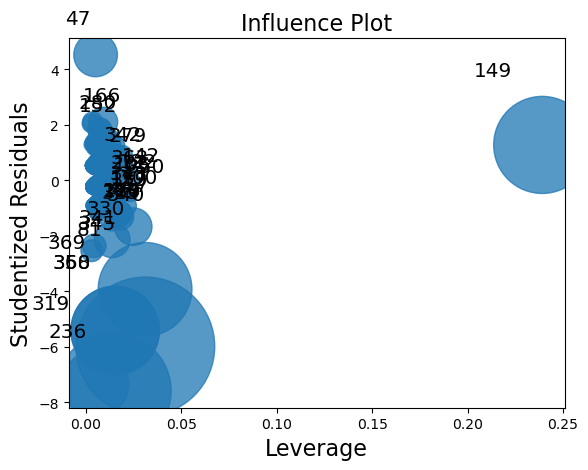

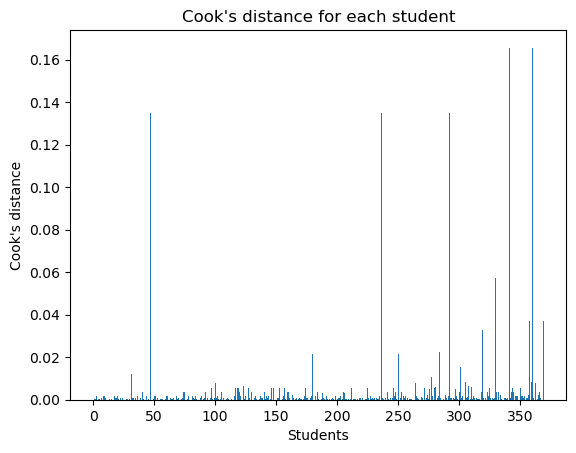

In [249]:

sm.graphics.influence_plot(model3, criterion="cooks", size=100)
plt.show()


plt.bar(range(0, len(cooks_d_list)), cooks_d_list)
plt.title('Cook\'s distance for each student')
plt.xlabel('Students')
plt.ylabel('Cook\'s distance')

plt.show()


In [250]:
cooks_d_list = model3.get_influence().cooks_distance[0]

print("Min:", cooks_d_list.min())
print("Max:", cooks_d_list.max())
print("Mean:", cooks_d_list.mean())
print()

Min: 4.5124466877917423e-07
Max: 0.3499412035527984
Mean: 0.004659067138096182



Again, the low mean suggests the outliers are not very influential.

In [251]:
cooks_d_list = model3.get_influence().cooks_distance[0]
sorted(cooks_d_list)[::-1][:30]

[0.3499412035527984,
 0.2417081840836946,
 0.16987253745456865,
 0.15822090978555764,
 0.14043522354346494,
 0.14043522354346494,
 0.07886537913917295,
 0.03251215192660555,
 0.023446562984852985,
 0.021124337924920605,
 0.013222709433468814,
 0.01050805943834629,
 0.008837850756333435,
 0.008525813291022788,
 0.008525813291022788,
 0.008525813291022788,
 0.008525813291022788,
 0.007989956427829488,
 0.007974534528189461,
 0.007974534528189461,
 0.007901179737208329,
 0.007578515085459206,
 0.007578515085459206,
 0.007337122517749143,
 0.006396500864405286,
 0.006016302058521781,
 0.005434101989940041,
 0.005434101989940041,
 0.005434101989940041,
 0.005133321505723645]

In [252]:
# get outliers above a threshold of 0.1
high_cooks_distance_students = {i: dist for i, dist in enumerate(cooks_d_list) if dist > 0.1}
high_cooks_distance_students

{149: 0.16987253745456865,
 319: 0.2417081840836946,
 341: 0.15822090978555764,
 358: 0.14043522354346494,
 360: 0.14043522354346494,
 369: 0.3499412035527984}

In [253]:
# show df of students with high cook's values

top_cooks_df = full_df.loc[high_cooks_distance_students.keys()][["pG1", "pG2", "pG3"]]

top_cooks_df

,pG1,pG2,pG3
149,0,11,11
319,11,9,0
341,7,5,0
358,7,7,0
360,7,7,0
369,5,8,0


The highest Cook values were students who had performed reasonably ok in the first two gradings, but for some reason failed receiving only a 1 or 0 in the final grade for the class.

These do not seem to have a large influence on the model, however.

### Multiple linear regression summary:

 The multiple linear regression using Portuguese grades (pG3) as the dependent variable found that both first and second portuguese grades (pG1 and pG2) are significant predictors of the final grade, explaining 79.5% of the variance in the final grades ($R^2 = 0.795$,$F(2, 367) = 713.1$, $p < .001$). However,the model did not meet the assumptions of homoskedasticity and normally distributed errors.

# Conclusion
### Linear regressions:
#### Second portuguese vs final portuguese grade 
There are some outliers distorting the outcome of the linear regression comparing the second and final portuguese grades possibly due to students who were absent from the final grading. 

Overall, the first linear regression found that there is a strong positive relationship between the second  Portuguese grades (pG2) and final Portuguese grades (pG3).

#### Weekday alcohol frequency vs final Mathematics grade.

The linear regression results indicated a negative relationship between weekday alcohol consumption and the final grades in Portuguese. As the frequency of weekday alcohol increases, the final grade tends to decrease.


### Multiple Linear regression:
#### First and second portuguese grades vs final portuguese grade
The multiple linear regresson found that using the first and second portuguese grades were good for explaining the final portuguese grade.

There were again some outliers where students had 0 grade results, however they didnt appear to have a large influence on the model.




